# Simple Linear Regression Implementation

This notebook demonstrates the implementation of Simple Linear Regression from scratch and using scikit-learn.

## Topics Covered:
1. Creating synthetic data
2. Implementation from scratch
3. Using scikit-learn
4. Model assumptions and diagnostics

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

%matplotlib inline


## 1. Creating Synthetic Data

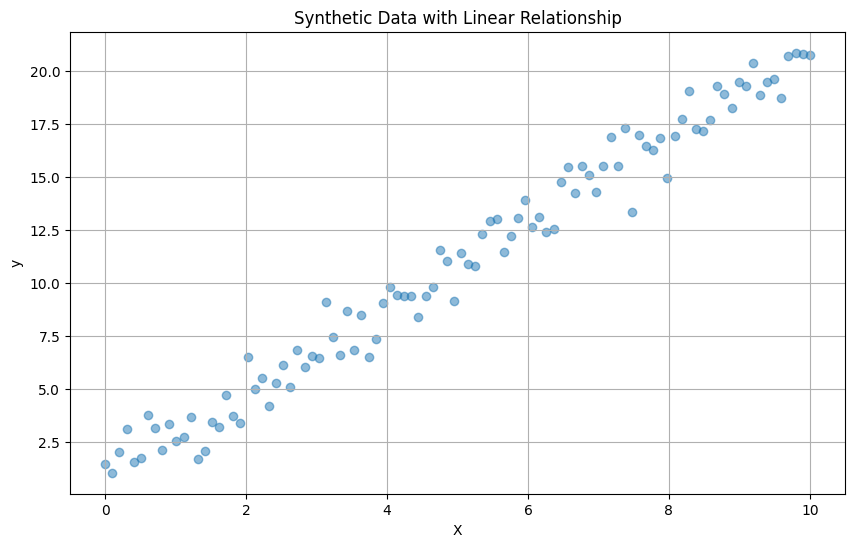

In [3]:
# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = 2 * X + 1 + np.random.normal(0, 1, 100)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5)
plt.title('Synthetic Data with Linear Relationship')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [ ]:
y = mx + C 

## 2. Implementation from Scratch

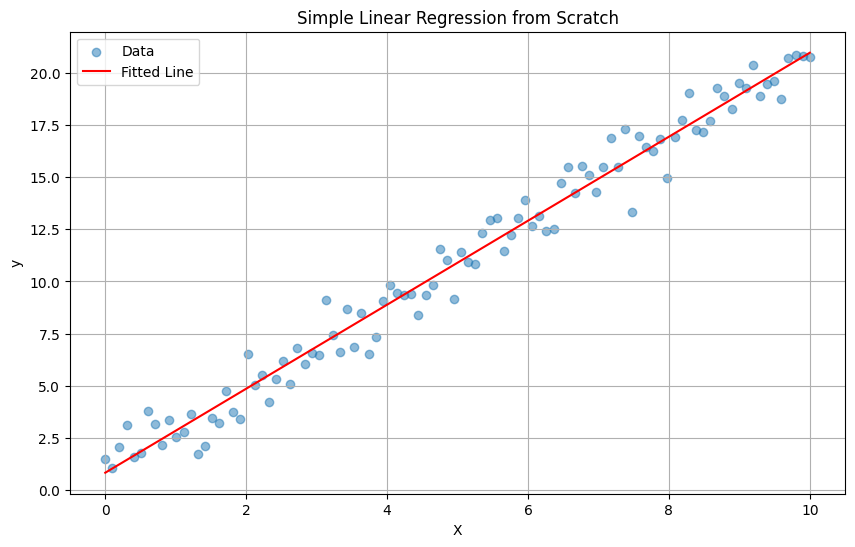

Slope: 2.01
Intercept: 0.83


In [4]:
class SimpleLinearRegression:
    def __init__(self):
        self.slope = None
        self.intercept = None
    
    def fit(self, X, y):
        # Calculate means
        X_mean = np.mean(X)
        y_mean = np.mean(y)
        
        # Calculate slope
        numerator = np.sum((X - X_mean) * (y - y_mean))
        denominator = np.sum((X - X_mean) ** 2)
        self.slope = numerator / denominator
        
        # Calculate intercept
        self.intercept = y_mean - self.slope * X_mean
        
    def predict(self, X):
        return self.slope * X + self.intercept

# Fit the model
model = SimpleLinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Data')
plt.plot(X, y_pred, 'r-', label='Fitted Line')
plt.title('Simple Linear Regression from Scratch')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print(f"Slope: {model.slope:.2f}")
print(f"Intercept: {model.intercept:.2f}")

## 3. Using scikit-learn

Slope: 2.01
Intercept: 0.82


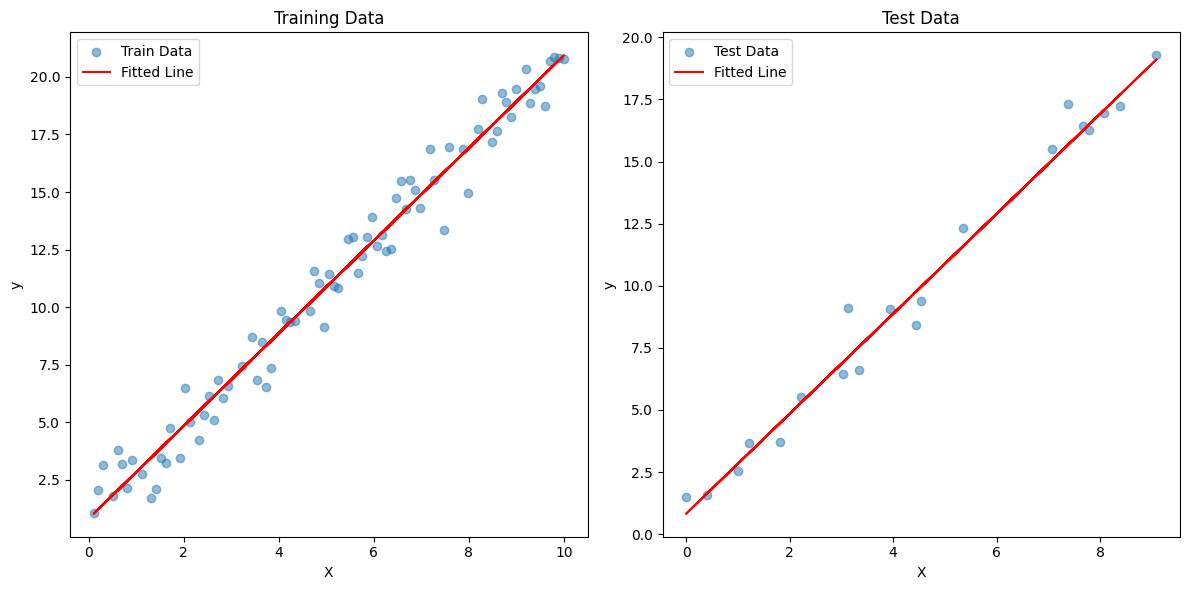

In [5]:
# Reshape X for scikit-learn
X_reshaped = X.reshape(-1, 1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

# Create and fit the model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

# Make predictions
y_train_pred = sklearn_model.predict(X_train)
y_test_pred = sklearn_model.predict(X_test)

# print the coefficients
print(f"Slope: {sklearn_model.coef_[0]:.2f}")
print(f"Intercept: {sklearn_model.intercept_:.2f}")

# Plot results

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.5, label='Train Data')
plt.plot(X_train, y_train_pred, 'r-', label='Fitted Line')
plt.title('Training Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, alpha=0.5, label='Test Data')
plt.plot(X_test, y_test_pred, 'r-', label='Fitted Line')
plt.title('Test Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Model Assumptions and Diagnostics

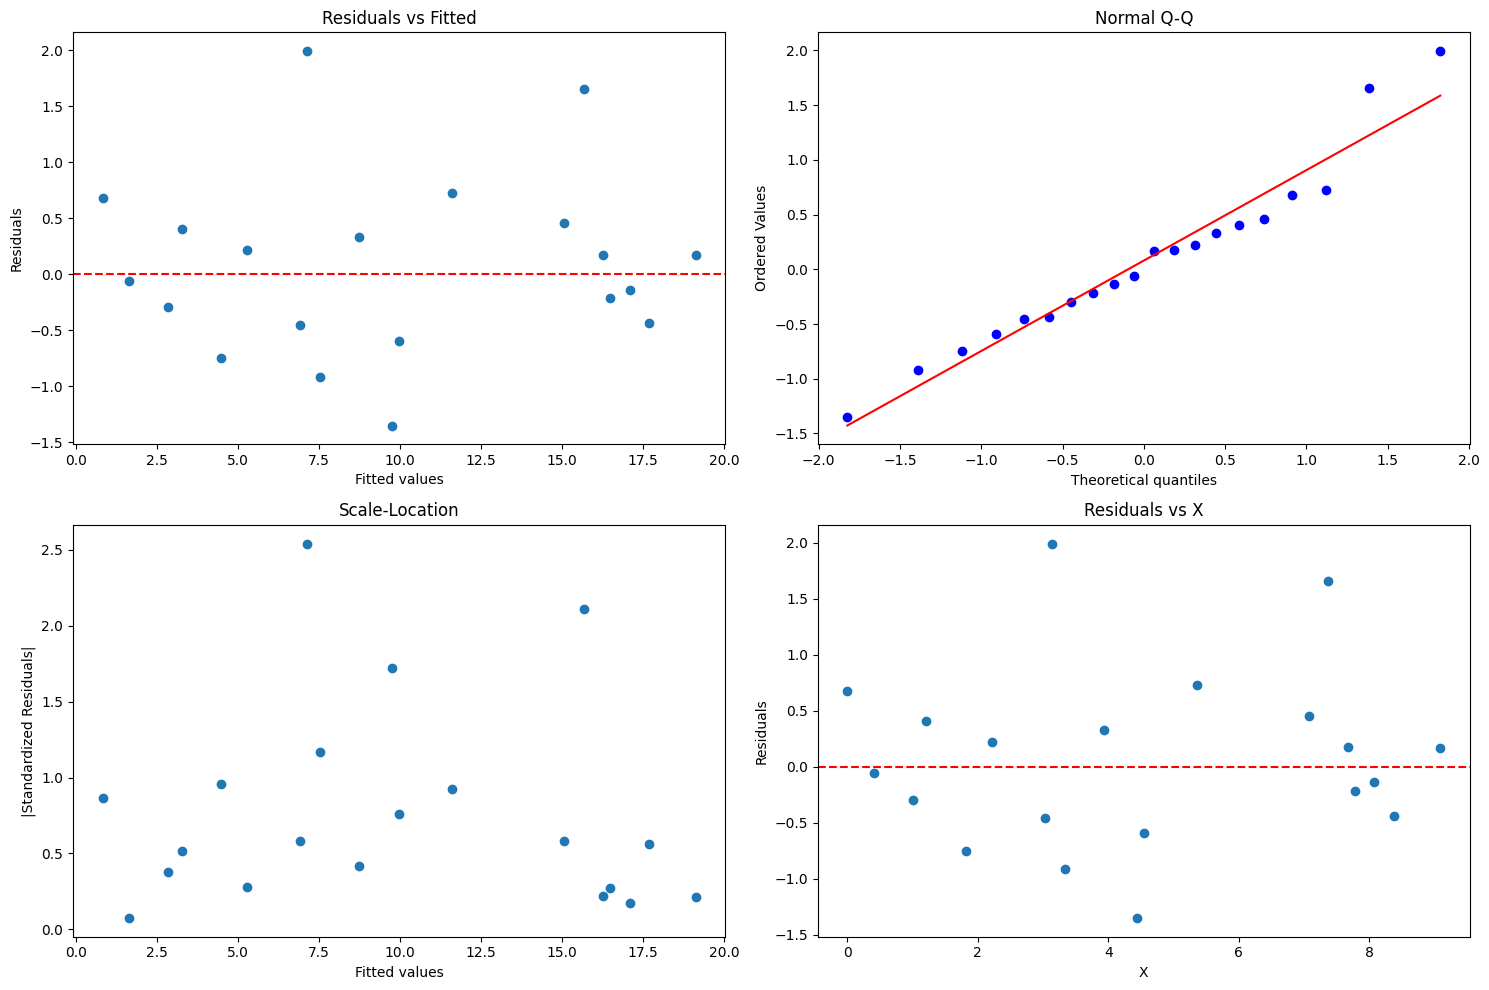

In [6]:
def plot_residual_diagnostics(y_true, y_pred, X):
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Residuals vs Fitted
    axes[0, 0].scatter(y_pred, residuals)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted')
    
    # Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Normal Q-Q')
    
    # Scale-Location
    standardized_residuals = residuals / np.std(residuals)
    axes[1, 0].scatter(y_pred, np.abs(standardized_residuals))
    axes[1, 0].set_xlabel('Fitted values')
    axes[1, 0].set_ylabel('|Standardized Residuals|')
    axes[1, 0].set_title('Scale-Location')
    
    # Residuals vs X
    axes[1, 1].scatter(X, residuals)
    axes[1, 1].axhline(y=0, color='r', linestyle='--')
    axes[1, 1].set_xlabel('X')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].set_title('Residuals vs X')
    
    plt.tight_layout()
    plt.show()

# Plot diagnostics
plot_residual_diagnostics(y_test, y_test_pred, X_test.ravel())